In [ ]:
#Activity log
#Bolortulga Seded
#24 February 2026
#Week 3 - Task 2: Outliers Detection and Normalisation 


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv('employees.csv')
print("Shape:", df.shape)
df.head()


Shape: (1000, 8)


,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services


In [4]:
num_cols = ['Salary', 'Bonus %']
print(df[num_cols].describe())

              Salary      Bonus %
count    1000.000000  1000.000000
mean    90662.181000    10.207555
std     32923.693342     5.528481
min     35013.000000     1.015000
25%     62613.000000     5.401750
50%     90428.000000     9.838500
75%    118740.250000    14.838000
max    149908.000000    19.944000


<function matplotlib.pyplot.show(close=None, block=None)>

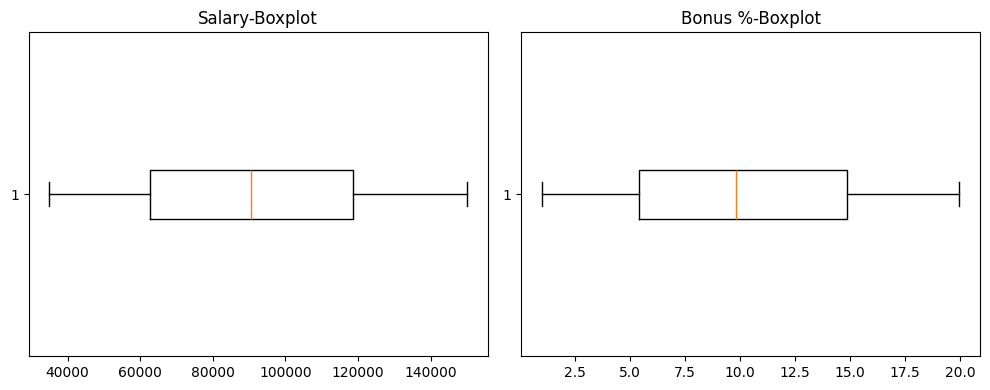

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
for i, col in enumerate(num_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_title(f"{col}-Boxplot")
plt.tight_layout()
plt.show

In [6]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1 

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bounds:\n",lower)
print("\nUpper bounds: \n", upper)

df_cleaned = df[~((df[num_cols] < lower) | (df[num_cols] > upper)).any(axis=1)]
print("\nOriginal shape:", df.shape)
print("Cleaned shape: ", df_cleaned.shape)
print("Rows removed: ", df.shape[0] - df_cleaned.shape[0])
    

Lower bounds:
 Salary    -21577.875000
Bonus %       -8.752625
dtype: float64

Upper bounds: 
 Salary     202931.125000
Bonus %        28.992375
dtype: float64

Original shape: (1000, 8)
Cleaned shape:  (1000, 8)
Rows removed:  0


In [7]:
X = df_cleaned[num_cols]

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print("After MinMaxScaler:")
print(pd.DataFrame(X_normalized, columns=num_cols).head())

After MinMaxScaler:
     Salary   Bonus %
0  0.542191  0.313276
1  0.234301  0.166675
2  0.831864  0.572825
3  0.902494  0.439801
4  0.574359  0.019758


In [8]:
scaler2 = StandardScaler()
X_standardized = scaler2.fit_transform(X)
print("After StandardScaler:")
print(pd.DataFrame(X_standardized, columns=num_cols).head())

After StandardScaler:
     Salary   Bonus %
0  0.201956 -0.590431
1 -0.873036 -1.092629
2  1.213345  0.298684
3  1.459947 -0.157003
4  0.314272 -1.595912
